# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

# **Importando datasets temáticos classificados e homologados**

In [3]:
# baixando datasets para o collab
import gdown

file_class_aborto = "1j6e5gnDPrjgVOhyD13hXR1CrfIZHQbJG" #Convergencias aborto
file_class_cloroquina = "1j-IzzcJsM7dl7qnorliVd2G_S4DYH3Me" #convergencias cloroquina
file_class_contas_suspensas = "1GXR1CJ8WdqnUN4nVS2ZjxrioGyUf9KXg" #convergencias contas suspensas
file_class_mandetta = "1DflkrifPiLZernoPmaTBOgE3XFb6uEgu" #convergencias mandetta

url_1 = f"https://drive.google.com/uc?id={file_class_aborto}"
url_2 = f"https://drive.google.com/uc?id={file_class_cloroquina}"
url_3 = f"https://drive.google.com/uc?id={file_class_contas_suspensas}"
url_4 = f"https://drive.google.com/uc?id={file_class_mandetta}"


gdown.download(url_1, "aborto_homologado.csv", quiet=False)
gdown.download(url_2, "cloroquina_homologado.csv", quiet=False)
gdown.download(url_3, "contas_suspensas_homologado.csv", quiet=False)
gdown.download(url_4, "mandetta_homologado.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1j6e5gnDPrjgVOhyD13hXR1CrfIZHQbJG
To: /content/aborto_homologado.csv
100%|██████████| 127k/127k [00:00<00:00, 53.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1j-IzzcJsM7dl7qnorliVd2G_S4DYH3Me
To: /content/cloroquina_homologado.csv
100%|██████████| 162k/162k [00:00<00:00, 50.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GXR1CJ8WdqnUN4nVS2ZjxrioGyUf9KXg
To: /content/contas_suspensas_homologado.csv
100%|██████████| 138k/138k [00:00<00:00, 44.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DflkrifPiLZernoPmaTBOgE3XFb6uEgu
To: /content/mandetta_homologado.csv
100%|██████████| 129k/129k [00:00<00:00, 55.0MB/s]


'mandetta_homologado.csv'

In [4]:
#Carregando e processando os datasets tematicos
def carregar_dataset(arquivo, tema):
    df = pd.read_csv(arquivo) #carregando o df
    df['Conflict'] = df['Conflict'].astype(int) #convertendo para int
    df['Tema'] = tema #registrando o tema
    return df[['tweet_1', 'tweet_2', 'Tema', 'Class', 'P(NoConflict)', 'P(Conflict)', 'Conflict']] #ordenando as colunas

df_aborto = carregar_dataset("aborto_homologado.csv", "Aborto")
df_cloroquina = carregar_dataset("cloroquina_homologado.csv", "Cloroquina")
df_contas_suspensas = carregar_dataset("contas_suspensas_homologado.csv","Contas suspensas")
df_mandetta = carregar_dataset("mandetta_homologado.csv", "Mandetta")

#**Análise exploratória dos dataset temáticos:**

In [5]:
#NUMERO TOTAL DE INSTANCIAS HOMOLOGADAS
print("NUMERO DE INSTANCIAS HOMOLOGADAS:")
print("Aborto: ", df_aborto.shape)
print("Cloroquina: ", df_cloroquina.shape)
print("Contas suspensas: ", df_contas_suspensas.shape)
print("Mandetta: ", df_mandetta.shape)
print("Total: ", df_aborto.shape[0] + df_cloroquina.shape[0] + df_contas_suspensas.shape[0] + df_mandetta.shape[0])

NUMERO DE INSTANCIAS HOMOLOGADAS:
Aborto:  (358, 7)
Cloroquina:  (400, 7)
Contas suspensas:  (400, 7)
Mandetta:  (365, 7)
Total:  1523


In [6]:
#CLASSIFICAÇÕES POR CLASSES
print("CLASSIFICAÇÕES POR CLASSES:")
print("Aborto:")
print("Conflito:", df_aborto[df_aborto['Conflict'] == 1].shape[0])
print("Não conflito:", df_aborto[df_aborto['Conflict'] == 0].shape[0])
print("indeterminado:", df_aborto[df_aborto['Conflict'] == -1].shape[0])
print()
print("Cloroquina:")
print("Conflito:", df_cloroquina[df_cloroquina['Conflict'] == 1].shape[0])
print("Não conflito:", df_cloroquina[df_cloroquina['Conflict'] == 0].shape[0])
print("indeterminado:", df_cloroquina[df_cloroquina['Conflict'] == -1].shape[0])
print()
print("Contas suspensas:")
print("Conflito:", df_contas_suspensas[df_contas_suspensas['Conflict'] == 1].shape[0])
print("Não conflito:", df_contas_suspensas[df_contas_suspensas['Conflict'] == 0].shape[0])
print("indeterminado:", df_contas_suspensas[df_contas_suspensas['Conflict'] == -1].shape[0])
print()
print("Mandetta:")
print("Conflito:", df_mandetta[df_mandetta['Conflict'] == 1].shape[0])
print("Não conflito:", df_mandetta[df_mandetta['Conflict'] == 0].shape[0])
print("indeterminado:", df_mandetta[df_mandetta['Conflict'] == -1].shape[0])


CLASSIFICAÇÕES POR CLASSES:
Aborto:
Conflito: 181
Não conflito: 166
indeterminado: 11

Cloroquina:
Conflito: 208
Não conflito: 174
indeterminado: 18

Contas suspensas:
Conflito: 221
Não conflito: 170
indeterminado: 9

Mandetta:
Conflito: 138
Não conflito: 225
indeterminado: 2


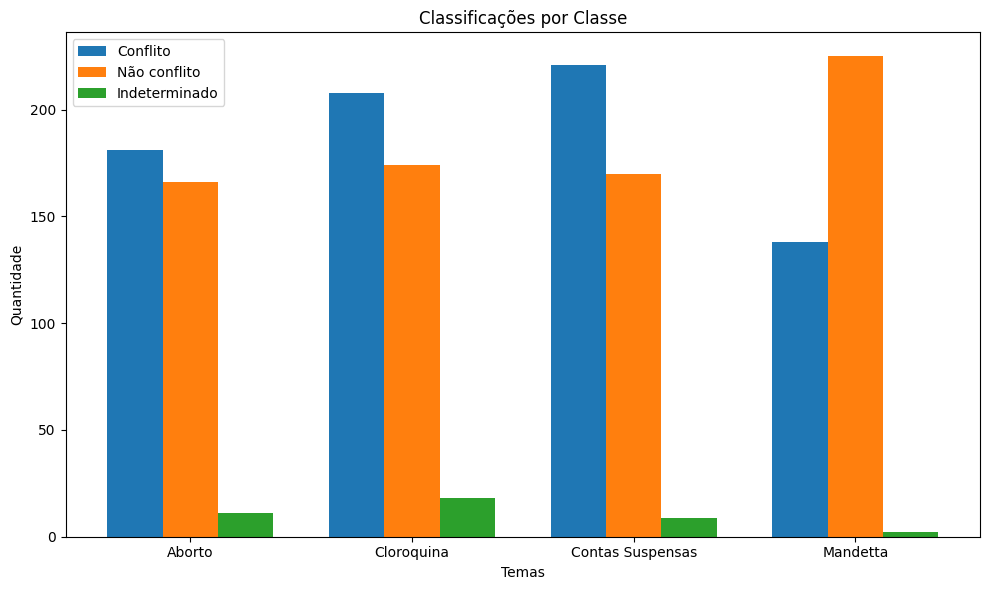

In [7]:
#GRAFICOS
#classificações por classes

#Organizando os dados
temas = ["Aborto", "Cloroquina", "Contas Suspensas", "Mandetta"]

conflito = [
    df_aborto[df_aborto['Conflict'] == 1].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == 1].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == 1].shape[0],
    df_mandetta[df_mandetta['Conflict'] == 1].shape[0]
]

nao_conflito = [
    df_aborto[df_aborto['Conflict'] == 0].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == 0].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == 0].shape[0],
    df_mandetta[df_mandetta['Conflict'] == 0].shape[0]
]

indeterminado = [
    df_aborto[df_aborto['Conflict'] == -1].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == -1].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == -1].shape[0],
    df_mandetta[df_mandetta['Conflict'] == -1].shape[0]
]

#posicionando barras

x = np.arange(len(temas)) #cria vetor [0,1,2,..,(len(temas))]

largura = 0.25

#desenhando grafico

plt.figure(figsize=(10, 6))

plt.bar(x - largura, conflito, width=largura, label="Conflito")
plt.bar(x, nao_conflito, width=largura, label="Não conflito")
plt.bar(x + largura, indeterminado, width=largura, label="Indeterminado")


plt.xticks(x, temas)

plt.title("Classificações por Classe")
plt.xlabel("Temas")
plt.ylabel("Quantidade")

plt.legend() #cria a caixinha de legenda

plt.tight_layout() #ajusta resolução para não cortar texto

plt.show()

#**Dataset final**

In [8]:
#CONCATENANDO DATASETS TEMÁTICOS
df_final = pd.concat([df_aborto, df_cloroquina, df_contas_suspensas, df_mandetta], ignore_index=True, axis = 0)
df_final.shape

(1523, 7)

In [9]:
df_final

,tweet_1,tweet_2,Tema,Class,P(NoConflict),P(Conflict),Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",Aborto,0,0.029973,0.970027,0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",Aborto,0,0.035262,0.964738,1
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,Aborto,0,0.035714,0.964286,0
3,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,Aborto,1,0.038269,0.961731,1
4,Pelo simples fato de que matar uma vida humana...,@ Vida é a partir do embrião.E embrião é vida....,Aborto,1,0.040479,0.959521,1
...,...,...,...,...,...,...,...
1518,"""E o Mandetta, a linha dele, como médico, era ...","Que coisa, um médico, defendendo vejam só, A VIDA",Mandetta,2,0.066134,0.933866,0
1519,para de endeusar o mandetta porra da pra ficar...,ninguém tá endeusando o cara que queria privat...,Mandetta,2,0.066362,0.933638,1
1520,Acabo de ouvir do presidente Jair Bolsonaro o ...,Nenhum capitalista gosta de quem trabalha. Ele...,Mandetta,2,0.066461,0.933539,0
1521,"Em sua despedida, Mandetta defende a vida, o S...","Caralho, Mandetta tava até ontem desmantelando...",Mandetta,2,0.066546,0.933454,1


In [10]:
#ANALISE EXPLORATÓRIA - DATASET FINAL
print("CLASSIFICAÇÕES POR CLASSES:")
print("conflito:", df_final[df_final['Conflict'] == 1].shape[0])
print("não conflito:", df_final[df_final['Conflict'] == 0].shape[0])
print("indeterminado:", df_final[df_final['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES:
conflito: 748
não conflito: 735
indeterminado: 40


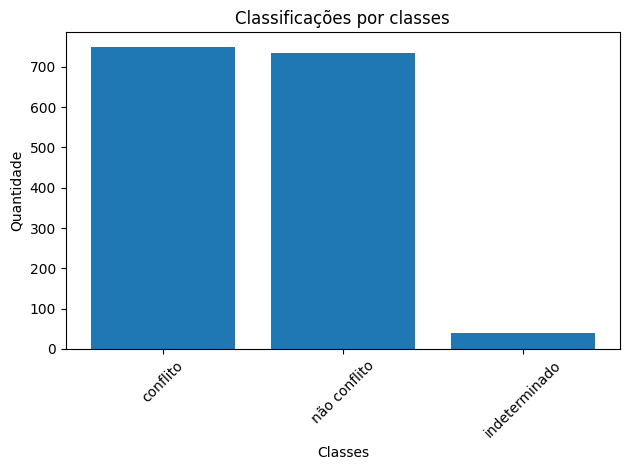

In [11]:
#GRAFICOS
#classificações por classes (conflito e não conflito)
conflitos = df_final[df_final['Conflict'] == 1].shape[0]
nao_conflitos = df_final[df_final['Conflict'] == 0].shape[0]
indeterminados = df_final[df_final['Conflict'] == -1].shape[0]

labels = ["conflito","não conflito", "indeterminado"]
values = [conflitos, nao_conflitos, indeterminados]
plt.figure()
plt.bar(labels, values)
plt.title("Classificações por classes")
plt.xlabel("Classes")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#classificações por estrutura de tweet (reply, quote, original)

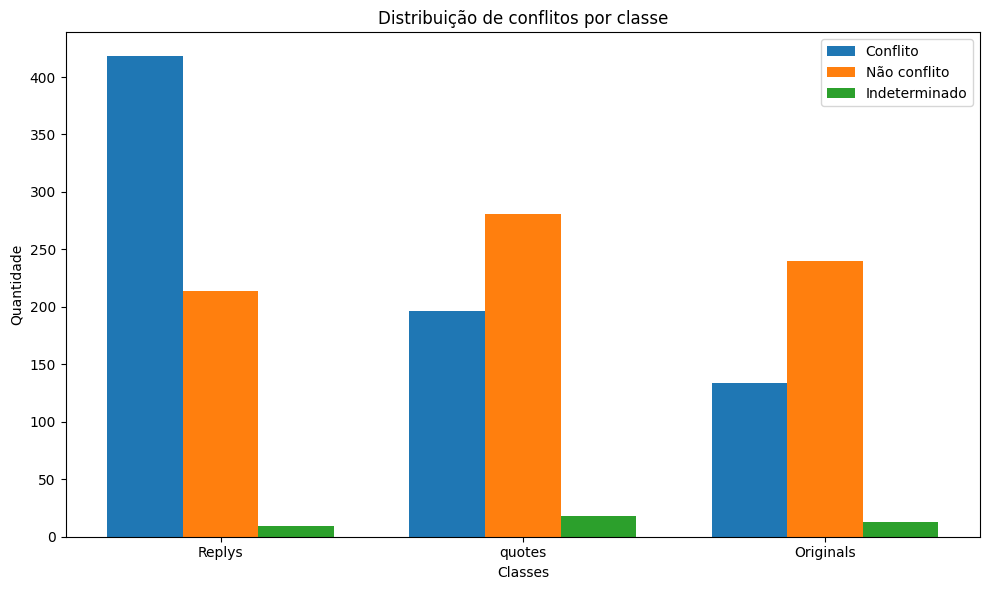

In [12]:
#Distribuição de conflitos por classes

#Separando as classes
reply = df_final[df_final['Class'] == 1]
quote = df_final[df_final['Class'] == 2]
original = df_final[df_final['Class'] == 0]

#Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply[reply['Conflict'] == 1].shape[0],
    quote[quote['Conflict'] == 1].shape[0],
    original[original['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply[reply['Conflict'] == 0].shape[0],
    quote[quote['Conflict'] == 0].shape[0],
    original[original['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply[reply['Conflict'] == -1].shape[0],
    quote[quote['Conflict'] == -1].shape[0],
    original[original['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por classe")

plt.legend()

plt.tight_layout()

plt.show()

In [13]:
df_final = df_final.drop(columns=['P(NoConflict)', 'P(Conflict)'])
df_final

,tweet_1,tweet_2,Tema,Class,Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",Aborto,0,0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",Aborto,0,1
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,Aborto,0,0
3,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,Aborto,1,1
4,Pelo simples fato de que matar uma vida humana...,@ Vida é a partir do embrião.E embrião é vida....,Aborto,1,1
...,...,...,...,...,...
1518,"""E o Mandetta, a linha dele, como médico, era ...","Que coisa, um médico, defendendo vejam só, A VIDA",Mandetta,2,0
1519,para de endeusar o mandetta porra da pra ficar...,ninguém tá endeusando o cara que queria privat...,Mandetta,2,1
1520,Acabo de ouvir do presidente Jair Bolsonaro o ...,Nenhum capitalista gosta de quem trabalha. Ele...,Mandetta,2,0
1521,"Em sua despedida, Mandetta defende a vida, o S...","Caralho, Mandetta tava até ontem desmantelando...",Mandetta,2,1


In [14]:
df_final.to_csv("dataset_conflitos.csv", index=False, encoding="utf-8")
files.download("dataset_conflitos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>